<a href="https://colab.research.google.com/github/sadhika-tech/deep-learning-lab/blob/main/Lab%202/xor_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from IPython.display import clear_output

np.random.seed(42)
tf.random.set_seed(42)

In [12]:
x=np.array([[0,0],[0,1],[1,0],[1,1]],dtype=np.float32)
y=np.array([[0],[1],[1],[0]],dtype=np.float32)

In [13]:
model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(4,activation='tanh'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),loss='binary_crossentropy',metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
def boundary(model,step):

    X=np.linspace(-0.5, 1.5, 200)
    Y=np.linspace(-0.5, 1.5, 200)
    xx,yy=np.meshgrid(X,Y)
    points=np.column_stack((xx.ravel(), yy.ravel()))

    pred=model.predict(points,verbose=0)
    pred=pred.reshape(xx.shape)

    plt.figure(figsize=(5,5))

    plt.contourf(xx,yy,pred,levels=20,alpha=0.6)
    plt.contour(xx,yy,pred,levels=[0.5],colors='black')

    plt.scatter(x[y[:,0]==0][:,0],x[y[:,0]==0][:,1],color="red",s=120,
        edgecolor="black",
        label="Output=0"
    )

    plt.scatter(x[y[:,0]==1][:,0],x[y[:,0]==1][:,1],color="blue",s=120,
        edgecolor="black",
        label="Output =1"
    )

    plt.title(f"Decision Boundary after Update {step}")
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.legend()
    #plt.savefig(f"epoch_{step}.png")
    plt.show()

In [15]:
print(x.shape)
print(y.shape)

(4, 2)
(4, 1)


In [16]:
class PlotBoundary(tf.keras.callbacks.Callback):

    def on_train_begin(self, logs=None):
        self.update=0

    def on_train_batch_end(self, batch, logs=None):

        self.update+= 1
        print(
            f"Weight Update: {self.update} | "
            f"Loss: {logs['loss']:.6f}"
        )

        if self.update%10==0:
            #clear_output(wait=True)

            print(f"Weight Update : {self.update}")
            print(f"Loss : {logs['loss']:.4f}")

            boundary(self.model, self.update)

        preds=(self.model.predict(x,verbose=0)>=0.5).astype(int)

        if np.array_equal(preds, y):
            print("\nXOR Learned Successfully!")
            print(f"Stopping at Weight Update {self.update}")
            boundary(self.model, "Final")
            self.model.stop_training = True

    def on_train_end(self, logs=None):

        print("\nTraining Complete")
        boundary(self.model, "Final")

Weight Update: 1 | Loss: 0.693147
Weight Update: 2 | Loss: 0.695492
Weight Update: 3 | Loss: 0.787320
Weight Update: 4 | Loss: 0.717437
Weight Update: 5 | Loss: 0.684668
Weight Update: 6 | Loss: 0.678795
Weight Update: 7 | Loss: 0.769498
Weight Update: 8 | Loss: 0.707719
Weight Update: 9 | Loss: 0.687337
Weight Update: 10 | Loss: 0.674213
Weight Update : 10
Loss : 0.6742


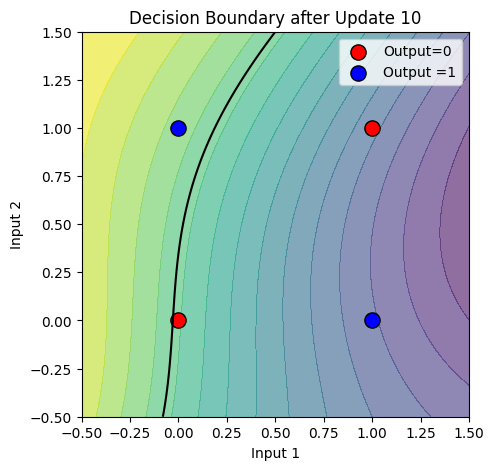

Weight Update: 11 | Loss: 0.761316
Weight Update: 12 | Loss: 0.704602
Weight Update: 13 | Loss: 0.690581
Weight Update: 14 | Loss: 0.671627
Weight Update: 15 | Loss: 0.755026
Weight Update: 16 | Loss: 0.702500
Weight Update: 17 | Loss: 0.693737
Weight Update: 18 | Loss: 0.669929
Weight Update: 19 | Loss: 0.749726
Weight Update: 20 | Loss: 0.700832
Weight Update : 20
Loss : 0.7008


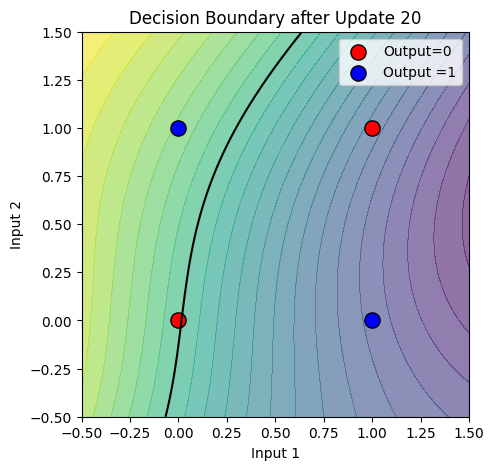

Weight Update: 21 | Loss: 0.696644
Weight Update: 22 | Loss: 0.668759
Weight Update: 23 | Loss: 0.745113
Weight Update: 24 | Loss: 0.699417
Weight Update: 25 | Loss: 0.699249
Weight Update: 26 | Loss: 0.667950
Weight Update: 27 | Loss: 0.741041
Weight Update: 28 | Loss: 0.698176
Weight Update: 29 | Loss: 0.701537
Weight Update: 30 | Loss: 0.667408
Weight Update : 30
Loss : 0.6674


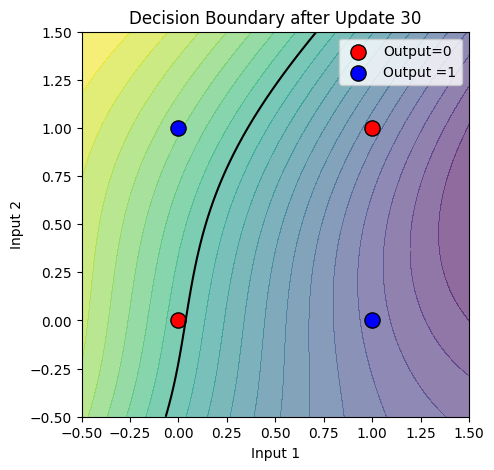

Weight Update: 31 | Loss: 0.737419
Weight Update: 32 | Loss: 0.697062
Weight Update: 33 | Loss: 0.703513
Weight Update: 34 | Loss: 0.667072
Weight Update: 35 | Loss: 0.734181
Weight Update: 36 | Loss: 0.696048
Weight Update: 37 | Loss: 0.705188
Weight Update: 38 | Loss: 0.666898
Weight Update: 39 | Loss: 0.731278
Weight Update: 40 | Loss: 0.695112
Weight Update : 40
Loss : 0.6951


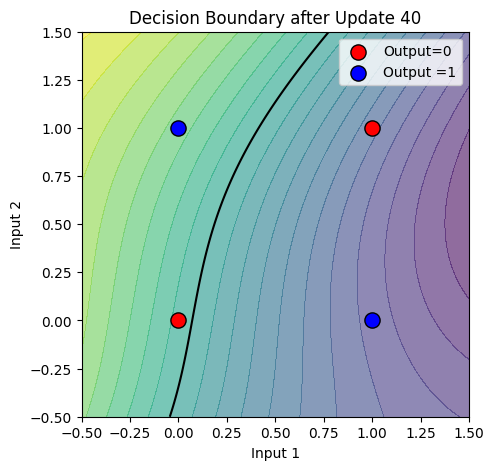

Weight Update: 41 | Loss: 0.706583
Weight Update: 42 | Loss: 0.666855
Weight Update: 43 | Loss: 0.728667
Weight Update: 44 | Loss: 0.694239
Weight Update: 45 | Loss: 0.707717
Weight Update: 46 | Loss: 0.666916
Weight Update: 47 | Loss: 0.726310
Weight Update: 48 | Loss: 0.693418
Weight Update: 49 | Loss: 0.708615
Weight Update: 50 | Loss: 0.667062
Weight Update : 50
Loss : 0.6671


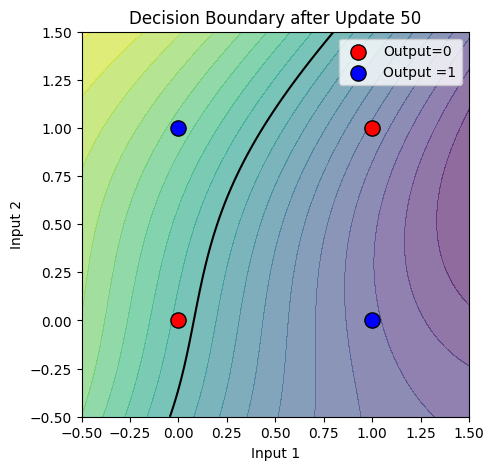

Weight Update: 51 | Loss: 0.724176
Weight Update: 52 | Loss: 0.692640
Weight Update: 53 | Loss: 0.709297
Weight Update: 54 | Loss: 0.667274
Weight Update: 55 | Loss: 0.722237
Weight Update: 56 | Loss: 0.691898
Weight Update: 57 | Loss: 0.709786
Weight Update: 58 | Loss: 0.667537
Weight Update: 59 | Loss: 0.720466
Weight Update: 60 | Loss: 0.691185
Weight Update : 60
Loss : 0.6912


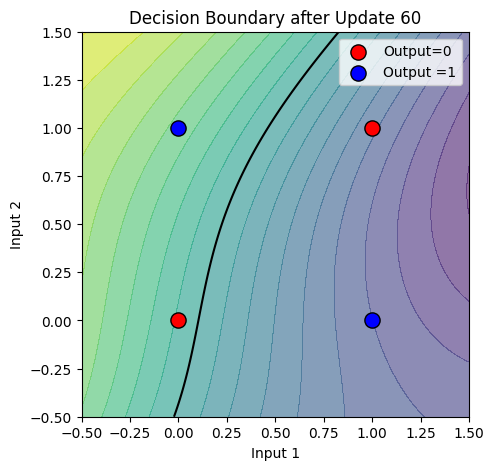

Weight Update: 61 | Loss: 0.710103
Weight Update: 62 | Loss: 0.667841
Weight Update: 63 | Loss: 0.718843
Weight Update: 64 | Loss: 0.690498
Weight Update: 65 | Loss: 0.710266
Weight Update: 66 | Loss: 0.668173
Weight Update: 67 | Loss: 0.717347
Weight Update: 68 | Loss: 0.689832
Weight Update: 69 | Loss: 0.710292
Weight Update: 70 | Loss: 0.668524
Weight Update : 70
Loss : 0.6685


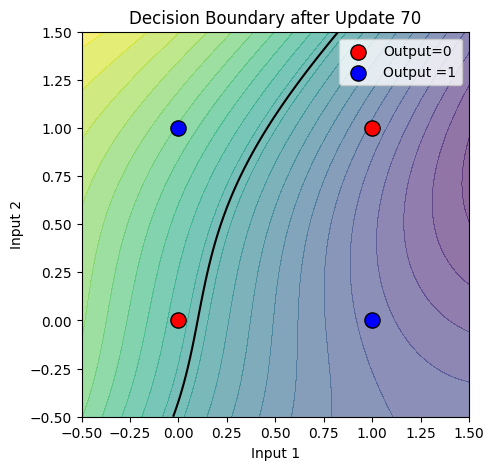

Weight Update: 71 | Loss: 0.715962
Weight Update: 72 | Loss: 0.689184
Weight Update: 73 | Loss: 0.710197
Weight Update: 74 | Loss: 0.668888
Weight Update: 75 | Loss: 0.714671
Weight Update: 76 | Loss: 0.688551
Weight Update: 77 | Loss: 0.709995
Weight Update: 78 | Loss: 0.669256
Weight Update: 79 | Loss: 0.713462
Weight Update: 80 | Loss: 0.687931
Weight Update : 80
Loss : 0.6879


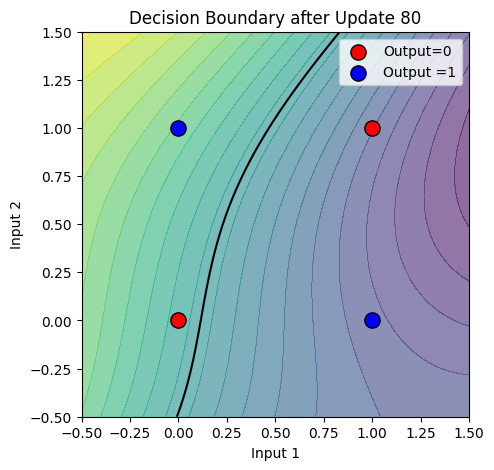

Weight Update: 81 | Loss: 0.709698
Weight Update: 82 | Loss: 0.669623
Weight Update: 83 | Loss: 0.712322
Weight Update: 84 | Loss: 0.687322
Weight Update: 85 | Loss: 0.709316
Weight Update: 86 | Loss: 0.669984
Weight Update: 87 | Loss: 0.711242
Weight Update: 88 | Loss: 0.686721
Weight Update: 89 | Loss: 0.708859
Weight Update: 90 | Loss: 0.670335
Weight Update : 90
Loss : 0.6703


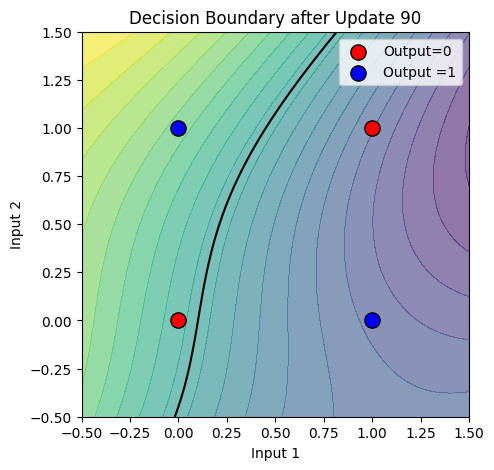

Weight Update: 91 | Loss: 0.710212
Weight Update: 92 | Loss: 0.686127
Weight Update: 93 | Loss: 0.708335
Weight Update: 94 | Loss: 0.670671
Weight Update: 95 | Loss: 0.709224
Weight Update: 96 | Loss: 0.685538
Weight Update: 97 | Loss: 0.707749
Weight Update: 98 | Loss: 0.670990
Weight Update: 99 | Loss: 0.708271
Weight Update: 100 | Loss: 0.684953
Weight Update : 100
Loss : 0.6850


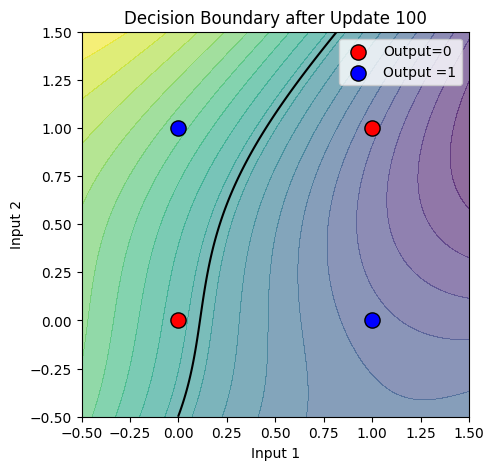

Weight Update: 101 | Loss: 0.707109
Weight Update: 102 | Loss: 0.671288
Weight Update: 103 | Loss: 0.707348
Weight Update: 104 | Loss: 0.684370
Weight Update: 105 | Loss: 0.706419
Weight Update: 106 | Loss: 0.671563
Weight Update: 107 | Loss: 0.706448
Weight Update: 108 | Loss: 0.683788
Weight Update: 109 | Loss: 0.705683
Weight Update: 110 | Loss: 0.671813
Weight Update : 110
Loss : 0.6718


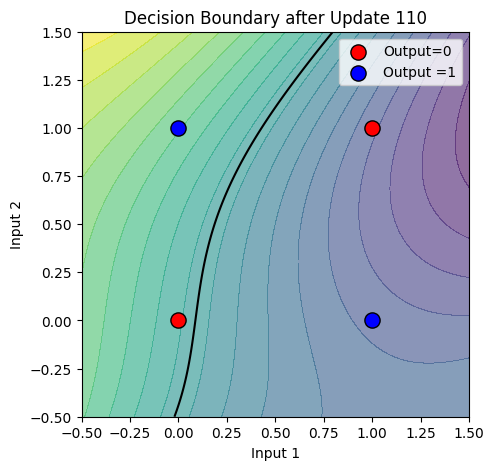

Weight Update: 111 | Loss: 0.705567
Weight Update: 112 | Loss: 0.683206
Weight Update: 113 | Loss: 0.704906
Weight Update: 114 | Loss: 0.672036
Weight Update: 115 | Loss: 0.704701
Weight Update: 116 | Loss: 0.682622
Weight Update: 117 | Loss: 0.704088
Weight Update: 118 | Loss: 0.672230
Weight Update: 119 | Loss: 0.703845
Weight Update: 120 | Loss: 0.682034
Weight Update : 120
Loss : 0.6820


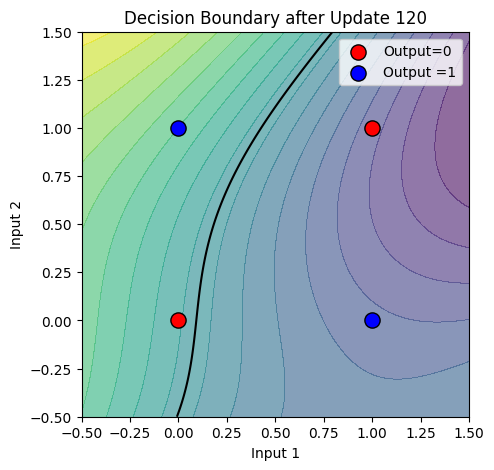

Weight Update: 121 | Loss: 0.703234
Weight Update: 122 | Loss: 0.672395
Weight Update: 123 | Loss: 0.702997
Weight Update: 124 | Loss: 0.681443
Weight Update: 125 | Loss: 0.702346
Weight Update: 126 | Loss: 0.672528
Weight Update: 127 | Loss: 0.702154
Weight Update: 128 | Loss: 0.680846
Weight Update: 129 | Loss: 0.701423
Weight Update: 130 | Loss: 0.672629
Weight Update : 130
Loss : 0.6726


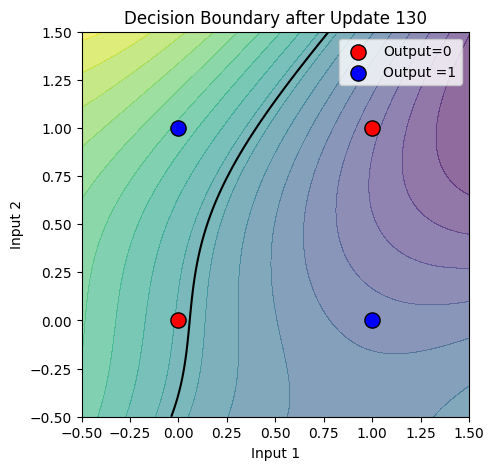

Weight Update: 131 | Loss: 0.701312
Weight Update: 132 | Loss: 0.680243
Weight Update: 133 | Loss: 0.700469
Weight Update: 134 | Loss: 0.672697
Weight Update: 135 | Loss: 0.700470
Weight Update: 136 | Loss: 0.679632
Weight Update: 137 | Loss: 0.699484
Weight Update: 138 | Loss: 0.672731
Weight Update: 139 | Loss: 0.699624
Weight Update: 140 | Loss: 0.679013
Weight Update : 140
Loss : 0.6790


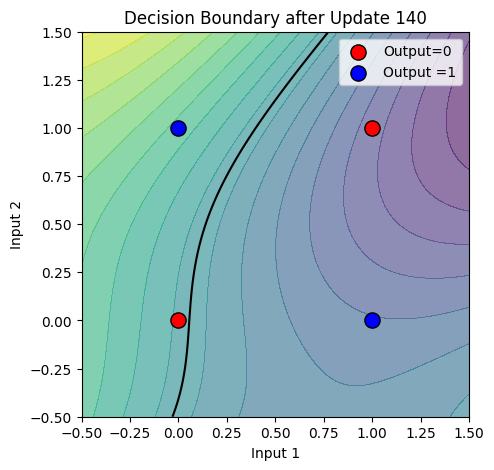

Weight Update: 141 | Loss: 0.698469
Weight Update: 142 | Loss: 0.672731
Weight Update: 143 | Loss: 0.698773
Weight Update: 144 | Loss: 0.678384
Weight Update: 145 | Loss: 0.697425
Weight Update: 146 | Loss: 0.672695
Weight Update: 147 | Loss: 0.697916
Weight Update: 148 | Loss: 0.677743
Weight Update: 149 | Loss: 0.696351
Weight Update: 150 | Loss: 0.672624
Weight Update : 150
Loss : 0.6726


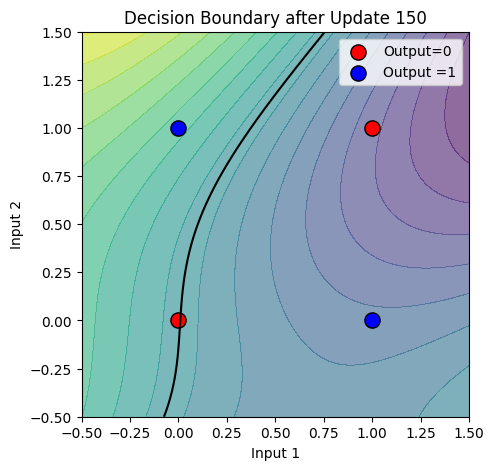

Weight Update: 151 | Loss: 0.697050
Weight Update: 152 | Loss: 0.677091
Weight Update: 153 | Loss: 0.695248
Weight Update: 154 | Loss: 0.672516
Weight Update: 155 | Loss: 0.696173
Weight Update: 156 | Loss: 0.676426
Weight Update: 157 | Loss: 0.694116
Weight Update: 158 | Loss: 0.672372
Weight Update: 159 | Loss: 0.695284
Weight Update: 160 | Loss: 0.675747
Weight Update : 160
Loss : 0.6757


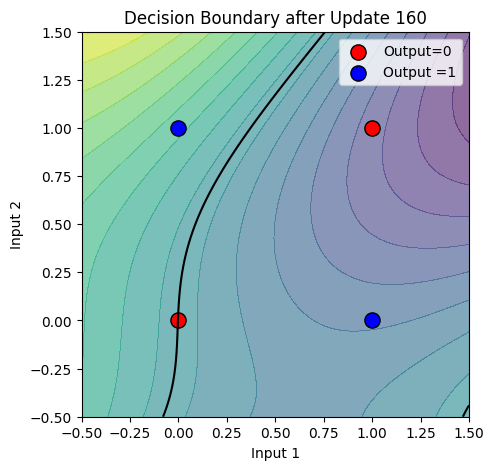

Weight Update: 161 | Loss: 0.692956
Weight Update: 162 | Loss: 0.672191
Weight Update: 163 | Loss: 0.694382
Weight Update: 164 | Loss: 0.675052
Weight Update: 165 | Loss: 0.691766
Weight Update: 166 | Loss: 0.671972
Weight Update: 167 | Loss: 0.693465
Weight Update: 168 | Loss: 0.674341
Weight Update: 169 | Loss: 0.690547
Weight Update: 170 | Loss: 0.671716
Weight Update : 170
Loss : 0.6717


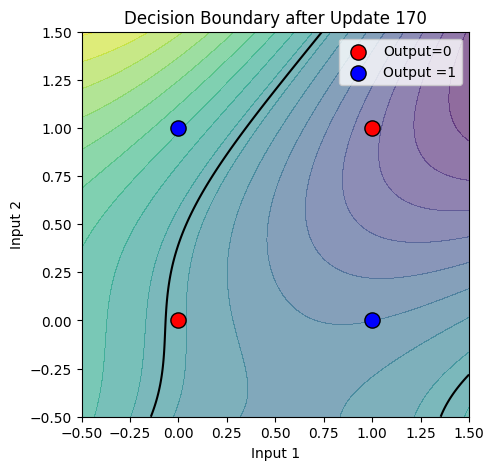

Weight Update: 171 | Loss: 0.692532
Weight Update: 172 | Loss: 0.673613
Weight Update: 173 | Loss: 0.689299
Weight Update: 174 | Loss: 0.671422
Weight Update: 175 | Loss: 0.691582
Weight Update: 176 | Loss: 0.672867
Weight Update: 177 | Loss: 0.688021
Weight Update: 178 | Loss: 0.671090
Weight Update: 179 | Loss: 0.690613
Weight Update: 180 | Loss: 0.672102
Weight Update : 180
Loss : 0.6721


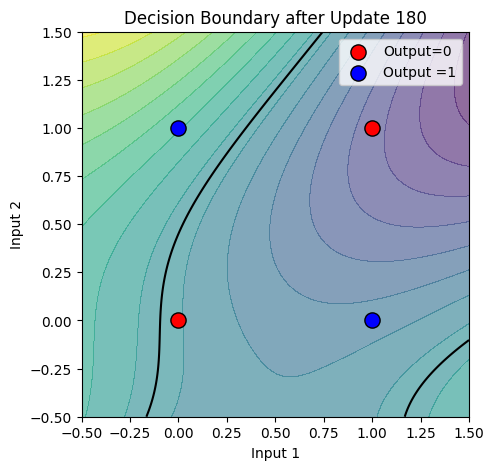

Weight Update: 181 | Loss: 0.686712
Weight Update: 182 | Loss: 0.670720
Weight Update: 183 | Loss: 0.689625
Weight Update: 184 | Loss: 0.671316
Weight Update: 185 | Loss: 0.685373
Weight Update: 186 | Loss: 0.670310
Weight Update: 187 | Loss: 0.688615
Weight Update: 188 | Loss: 0.670508
Weight Update: 189 | Loss: 0.684002
Weight Update: 190 | Loss: 0.669862
Weight Update : 190
Loss : 0.6699


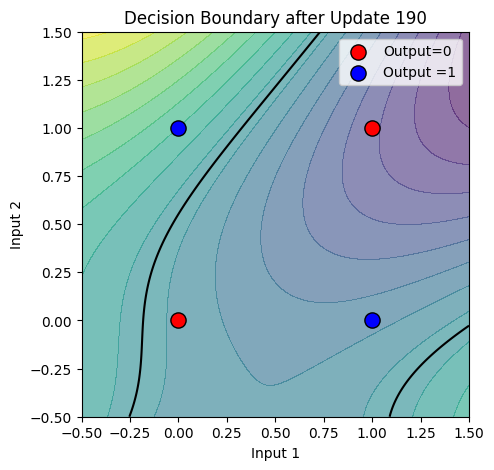

Weight Update: 191 | Loss: 0.687584
Weight Update: 192 | Loss: 0.669678
Weight Update: 193 | Loss: 0.682599
Weight Update: 194 | Loss: 0.669375
Weight Update: 195 | Loss: 0.686529
Weight Update: 196 | Loss: 0.668825
Weight Update: 197 | Loss: 0.681164
Weight Update: 198 | Loss: 0.668848
Weight Update: 199 | Loss: 0.685450
Weight Update: 200 | Loss: 0.667947
Weight Update : 200
Loss : 0.6679


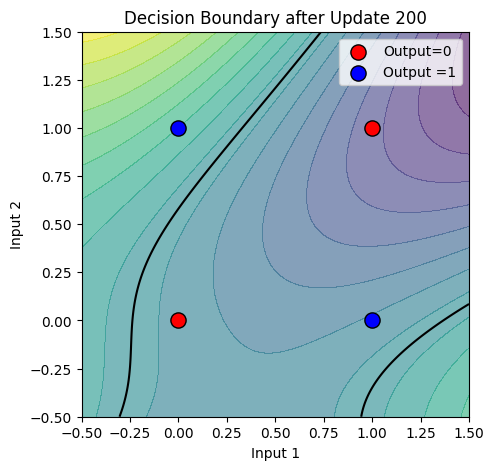

Weight Update: 201 | Loss: 0.679696
Weight Update: 202 | Loss: 0.668282
Weight Update: 203 | Loss: 0.684346
Weight Update: 204 | Loss: 0.667043
Weight Update: 205 | Loss: 0.678193
Weight Update: 206 | Loss: 0.667675
Weight Update: 207 | Loss: 0.683216
Weight Update: 208 | Loss: 0.666113
Weight Update: 209 | Loss: 0.676656
Weight Update: 210 | Loss: 0.667029
Weight Update : 210
Loss : 0.6670


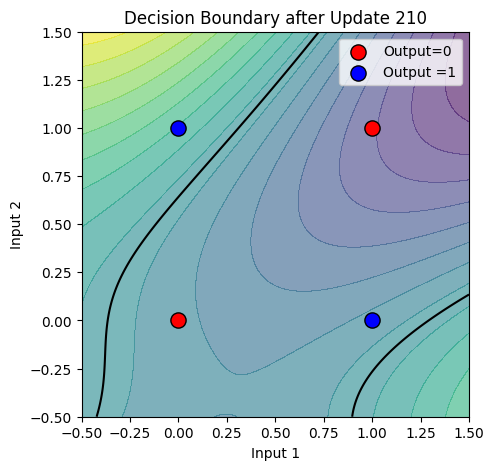

Weight Update: 211 | Loss: 0.682058
Weight Update: 212 | Loss: 0.665155
Weight Update: 213 | Loss: 0.675083
Weight Update: 214 | Loss: 0.666342
Weight Update: 215 | Loss: 0.680873
Weight Update: 216 | Loss: 0.664168
Weight Update: 217 | Loss: 0.673474
Weight Update: 218 | Loss: 0.665615
Weight Update: 219 | Loss: 0.679658
Weight Update: 220 | Loss: 0.663151
Weight Update : 220
Loss : 0.6632


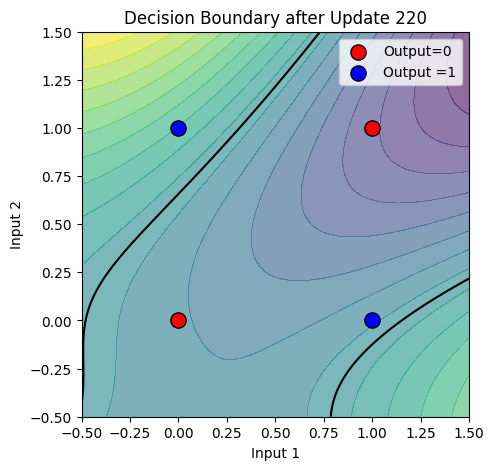

Weight Update: 221 | Loss: 0.671827
Weight Update: 222 | Loss: 0.664847
Weight Update: 223 | Loss: 0.678413
Weight Update: 224 | Loss: 0.662103
Weight Update: 225 | Loss: 0.670142
Weight Update: 226 | Loss: 0.664038
Weight Update: 227 | Loss: 0.677137
Weight Update: 228 | Loss: 0.661023
Weight Update: 229 | Loss: 0.668418
Weight Update: 230 | Loss: 0.663187
Weight Update : 230
Loss : 0.6632


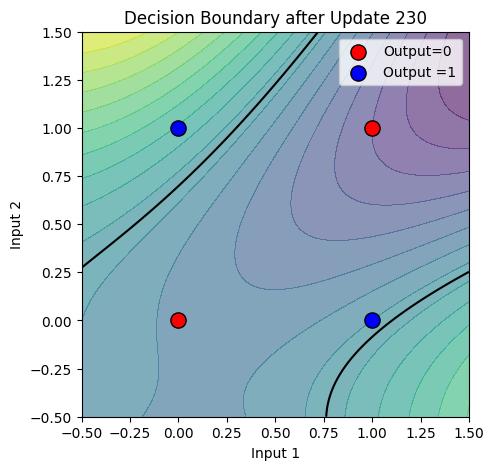

Weight Update: 231 | Loss: 0.675829
Weight Update: 232 | Loss: 0.659910
Weight Update: 233 | Loss: 0.666654
Weight Update: 234 | Loss: 0.662294
Weight Update: 235 | Loss: 0.674488
Weight Update: 236 | Loss: 0.658763
Weight Update: 237 | Loss: 0.664849
Weight Update: 238 | Loss: 0.661360
Weight Update: 239 | Loss: 0.673113

XOR Learned Successfully!
Stopping at Weight Update 239


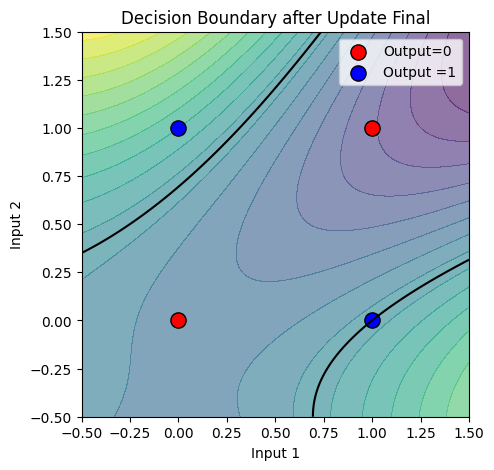


Training Complete


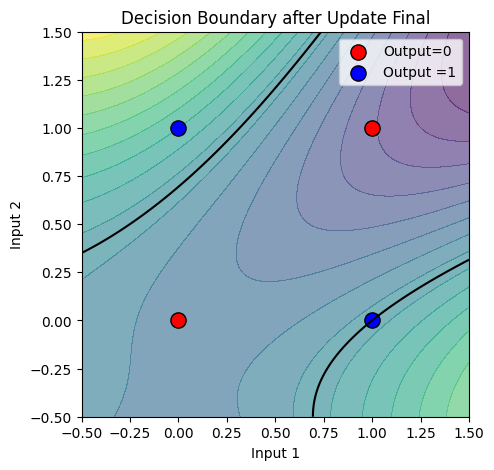

In [17]:
history=model.fit(x,y,epochs=3000,batch_size=1,shuffle=False,verbose=0,callbacks=[PlotBoundary()])

In [18]:
print("\nTraining Complete\n")
preds=model.predict(x)
print("Probabilities:")
print(np.round(preds,4))

print("\nPredicted Classes:")
print((preds>=0.5).astype(int))

print("\nExpected Classes:")
print(y.astype(int))


Training Complete

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Probabilities:
[[0.4849]
 [0.5201]
 [0.5   ]
 [0.4572]]

Predicted Classes:
[[0]
 [1]
 [1]
 [0]]

Expected Classes:
[[0]
 [1]
 [1]
 [0]]


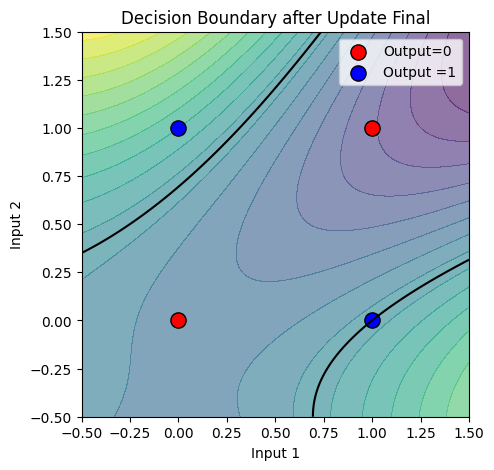

In [19]:
boundary(model,"Final")